In [1]:
from factors import *

In [2]:
bt = BackTester(fc_name_list=['fac_cumret', 'fac_upperline', 'fac_winrate'],
                instrument_type='futures_continuous_contract',
                instrument_id_list = 'C0',
                fc_freq = '1d',
                start_time='20230101',
                end_time='20260310',
                portfolio_adjust_method = '1D',
                interest_method = 'compound',
                risk_free_rate=False,
                n_jobs = 5
                )
bt.backtest()

In [5]:
bt.data

,time,instrument_id,open,high,low,close,volume,position
0,2023-01-03,C0,2829,2842,2817,2840,301325,705314
1,2023-01-04,C0,2840,2877,2838,2875,489218,711148
2,2023-01-05,C0,2875,2882,2859,2878,341944,714472
3,2023-01-06,C0,2873,2892,2867,2886,368002,731213
4,2023-01-09,C0,2882,2895,2879,2890,306730,744645
...,...,...,...,...,...,...,...,...
763,2026-03-04,C0,2373,2385,2369,2379,555128,1464914
764,2026-03-05,C0,2379,2395,2378,2384,584219,1484708
765,2026-03-06,C0,2386,2407,2384,2393,790836,1519542
766,2026-03-09,C0,2392,2443,2386,2395,1545357,1435081


In [4]:
# self = bt
# Data = self.data
# df = Data.copy()
#
# df = df.sort_values(by='time', ascending=True)
# df = df.set_index(['time', 'instrument_id'])
#
# fc_class_list = [resolve_factor_class(fc_name) for fc_name in self.fc_name_list]
# f = lambda x: get_factor_value_for_one_factor(df, x)
#
# with Parallel(n_jobs=self.n_jobs) as parallel:
#     mapper_list = parallel(delayed(f)(fc_class) for fc_class in fc_class_list)
# mapper_list = [x.reset_index() for x in mapper_list]

In [12]:
bt.fc_name_with_param_list

['fac_cumret_1_50',
 'fac_cumret_1_100',
 'fac_cumret_2_50',
 'fac_cumret_2_100',
 'fac_cumret_3_50',
 'fac_cumret_3_100',
 'fac_upperline_10',
 'fac_upperline_30',
 'fac_winrate_10',
 'fac_winrate_20',
 'fac_winrate_30']

In [16]:
df = bt.data.copy()

In [20]:
def _get_fee_for_instrument(Data: pd.DataFrame) -> float:
    instrument_ids = Data['instrument_id'].dropna().unique().tolist()
    if len(instrument_ids) != 1:
        raise ValueError('Fee lookup expects data of one instrument only.')
    instrument_id = instrument_ids[0]
    if instrument_id not in FEE:
        raise ValueError(f'Missing fee config for instrument_id={instrument_id}. Please update utils/params.py FEE.')
    return float(FEE[instrument_id])
fee = _get_fee_for_instrument(df)
fc_col = bt.fc_name_with_param_list
fee

0.0002

In [14]:
bt.performance_dc['C0']['fac_cumret_1_50']['daily_gross_ret'].copy()

,time,fac_cumret_1_50
0,2023-01-03,0.000000
1,2023-01-04,0.000152
2,2023-01-05,-0.000005
3,2023-01-06,0.000017
4,2023-01-09,0.000012
...,...,...
763,2026-03-04,0.000003
764,2026-03-05,0.000005
765,2026-03-06,0.000004
766,2026-03-09,-0.000001


In [25]:
df[fc_col].ffill().fillna(0)

,fac_cumret_1_50,fac_cumret_1_100,fac_cumret_2_50,fac_cumret_2_100,fac_cumret_3_50,fac_cumret_3_100,fac_upperline_10,fac_upperline_30,fac_winrate_10,fac_winrate_20,fac_winrate_30
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.083333,1.083333,0.0,0.00,0.000000
1,0.012324,0.012324,0.000000,0.000000,0.000000,0.000000,9.791667,9.791667,0.0,0.00,0.000000
2,0.006684,0.006684,0.013380,0.013380,0.000000,0.000000,6.673611,6.673611,0.0,0.00,0.000000
3,0.005382,0.005382,0.008603,0.008603,0.016197,0.016197,5.796875,5.796875,0.0,0.00,0.000000
4,0.004383,0.004383,0.007125,0.007125,0.010707,0.010707,5.504167,5.504167,0.0,0.00,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
763,0.001284,0.000963,0.002494,0.001910,0.003793,0.002928,11.836190,4.978093,0.7,0.65,0.566667
764,0.001550,0.000924,0.002837,0.001892,0.004044,0.002835,10.236190,5.525712,0.7,0.70,0.600000
765,0.001680,0.001049,0.003232,0.001979,0.004516,0.002943,10.852857,5.697239,0.7,0.70,0.600000
766,0.001660,0.001132,0.003343,0.002185,0.004893,0.003112,11.419524,5.976933,0.8,0.75,0.633333


In [4]:
bt.ts_performance_summary

,Gross Return,Net Return,Gross Volatility,Net Volatility,Gross Sharpe,Net Sharpe,Gross Sortino,Net Sortino,Gross MaxDD,Net MaxDD,...,Turnover,TS IC,TS RankIC,T-corr,count,all,Factor Name,Factor Freq,Fee,Instrument ID
year,,,,,,,,,,,,,,,,,,,,,
2023,0.000428,0.000414,0.000202,0.000200,2.119748,2.070893,4.667747,4.546063,0.000118,0.000120,...,0.000272,0.142099,0.129478,15.556349,1.0,NaN,fac_cumret_1_50,1d,0.0002,C0
2024,0.000193,0.000185,0.000150,0.000150,1.286048,1.233117,1.569669,1.537650,0.000069,0.000070,...,0.000158,0.095230,0.104134,15.556349,1.0,NaN,fac_cumret_1_50,1d,0.0002,C0
2025,0.000131,0.000125,0.000095,0.000095,1.379965,1.316451,2.023482,1.963745,0.000060,0.000060,...,0.000123,0.090319,0.071158,15.588457,1.0,NaN,fac_cumret_1_50,1d,0.0002,C0
2026,0.000507,0.000500,0.000105,0.000104,4.849837,4.788807,13.730050,13.135739,0.000014,0.000014,...,0.000142,0.120841,0.023077,6.403124,1.0,NaN,fac_cumret_1_50,1d,0.0002,C0
all,0.000264,0.000255,0.000153,0.000152,1.727439,1.676176,2.786738,2.744100,0.000118,0.000120,...,0.000182,0.127282,0.122591,768.000000,NaN,NaN,fac_cumret_1_50,1d,0.0002,C0
2023,0.000321,0.000311,0.000176,0.000174,1.827750,1.792389,5.622437,5.460965,0.000062,0.000063,...,0.000200,0.129049,0.102794,15.556349,1.0,NaN,fac_cumret_1_100,1d,0.0002,C0
2024,0.000081,0.000077,0.000120,0.000120,0.673209,0.640900,0.728309,0.710385,0.000080,0.000081,...,0.000077,0.029468,0.058797,15.556349,1.0,NaN,fac_cumret_1_100,1d,0.0002,C0
2025,0.000029,0.000025,0.000057,0.000057,0.505681,0.442142,0.704264,0.620189,0.000051,0.000052,...,0.000073,0.032093,0.041798,15.588457,1.0,NaN,fac_cumret_1_100,1d,0.0002,C0
2026,0.000259,0.000255,0.000047,0.000047,5.537018,5.473941,14.955109,14.593159,0.000007,0.000007,...,0.000068,0.056945,0.145598,6.403124,1.0,NaN,fac_cumret_1_100,1d,0.0002,C0


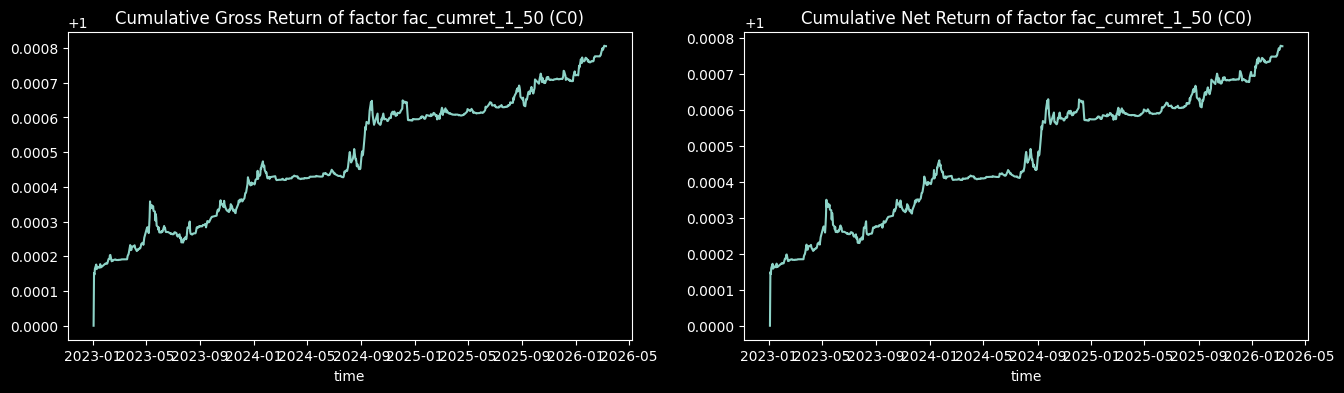

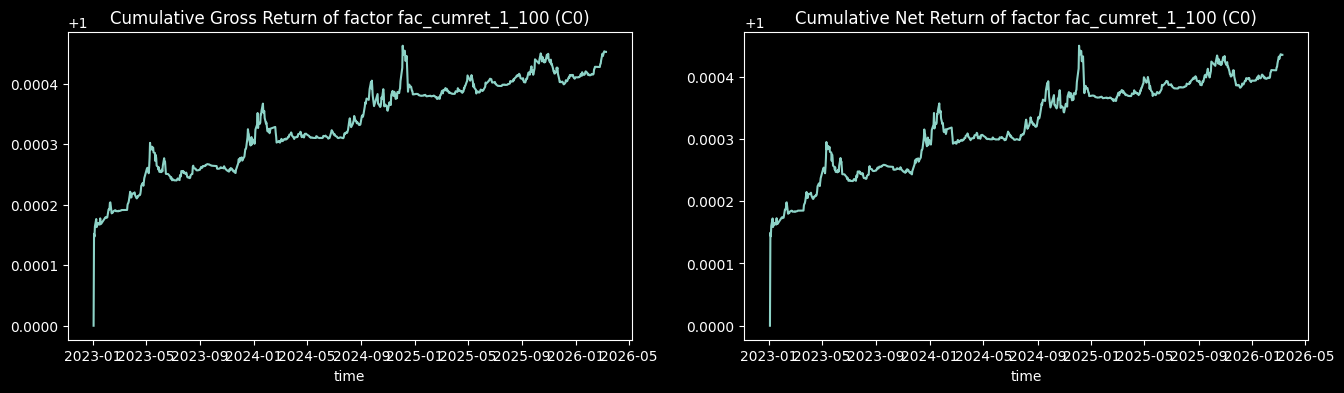

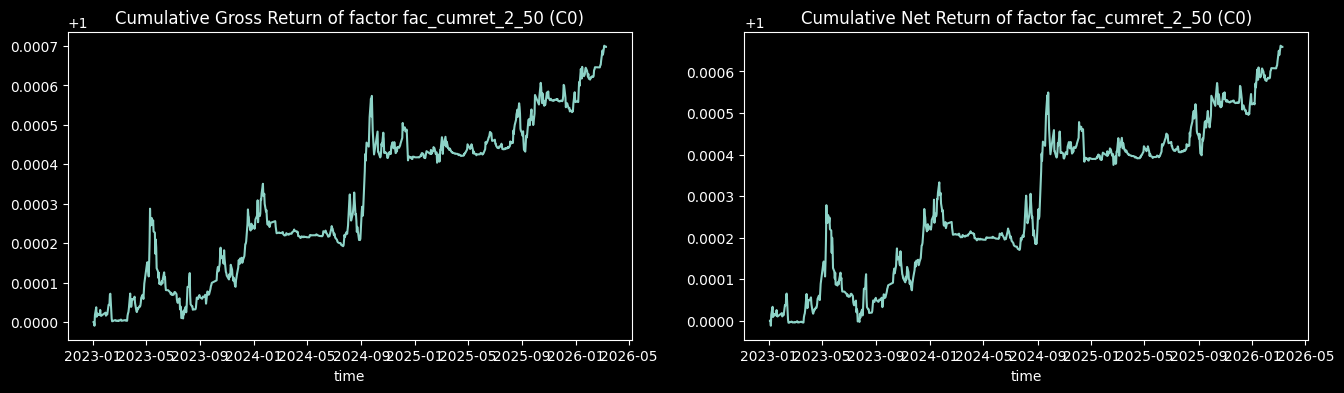

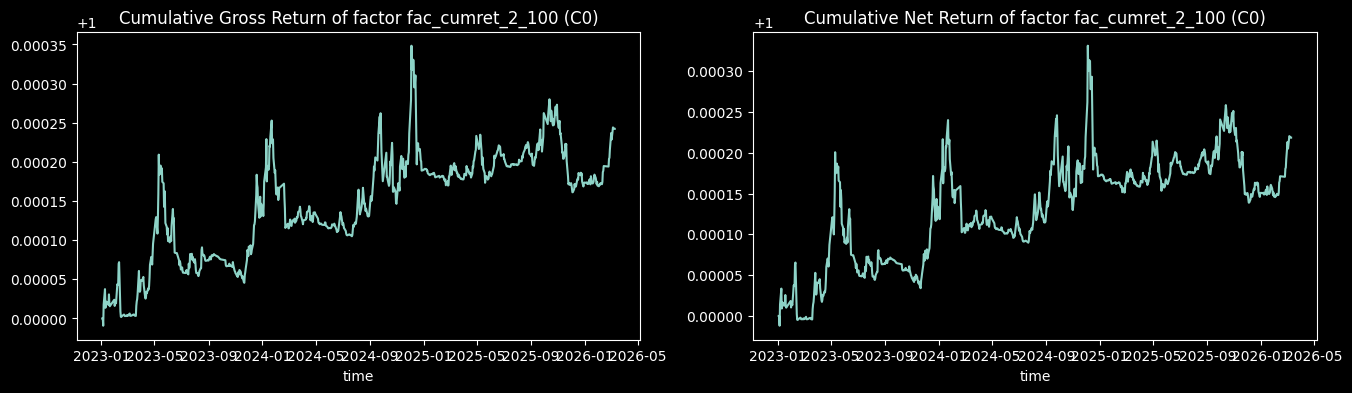

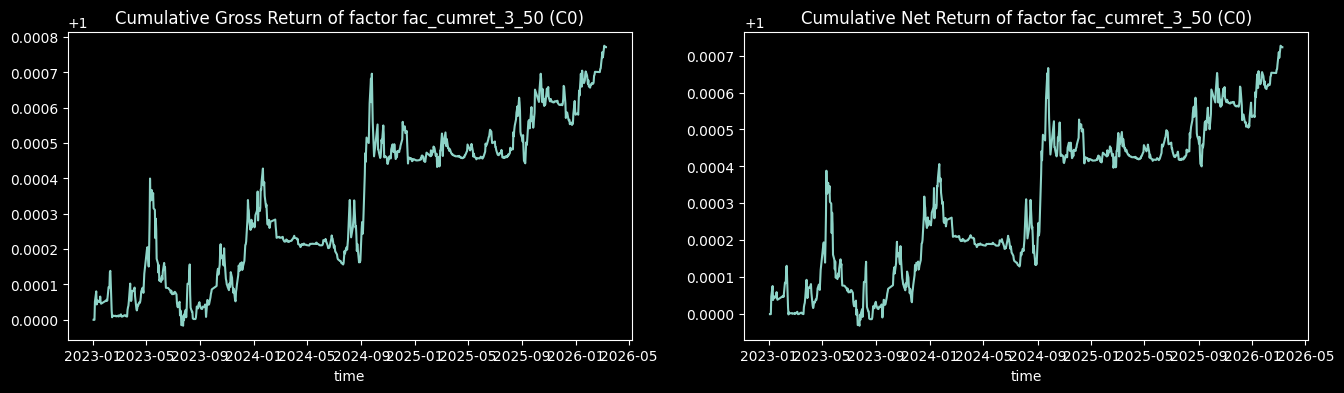

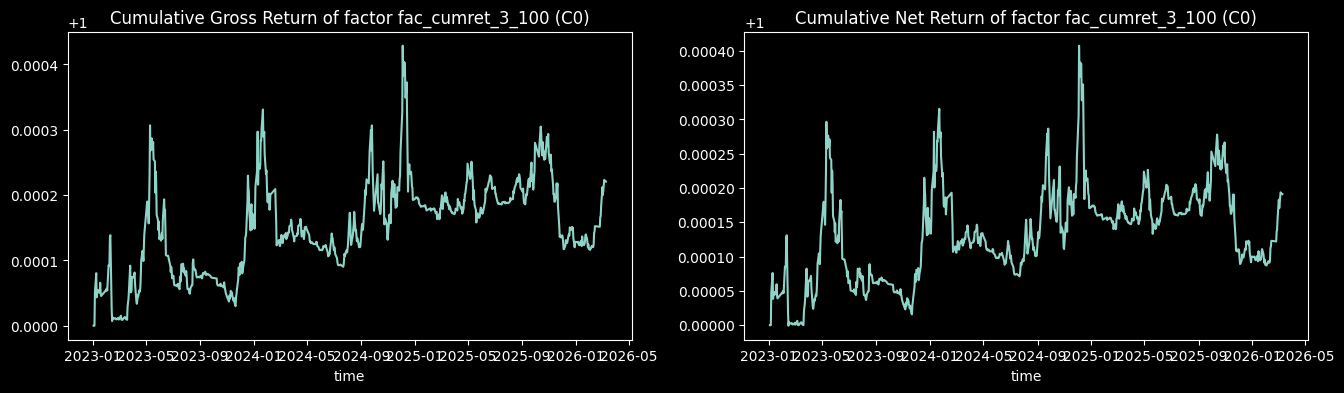

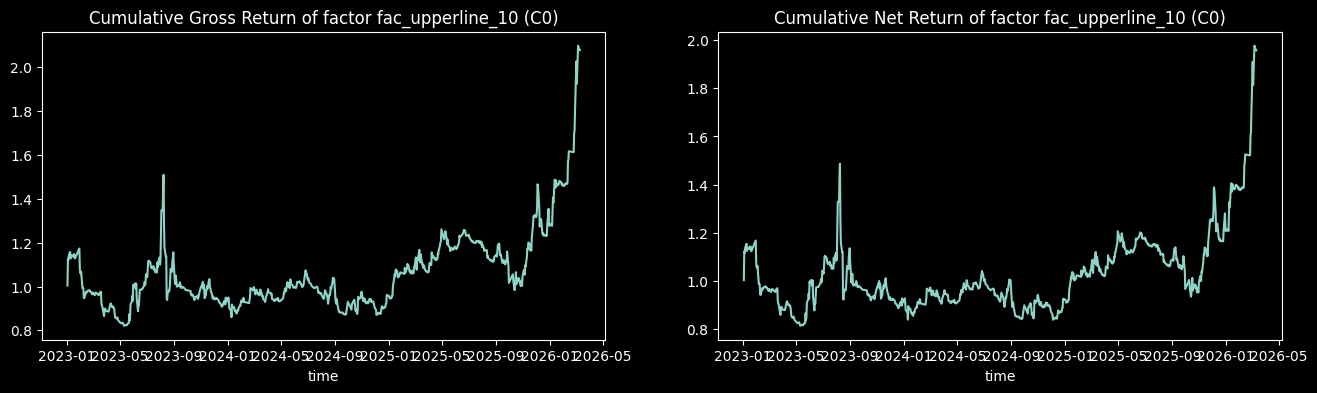

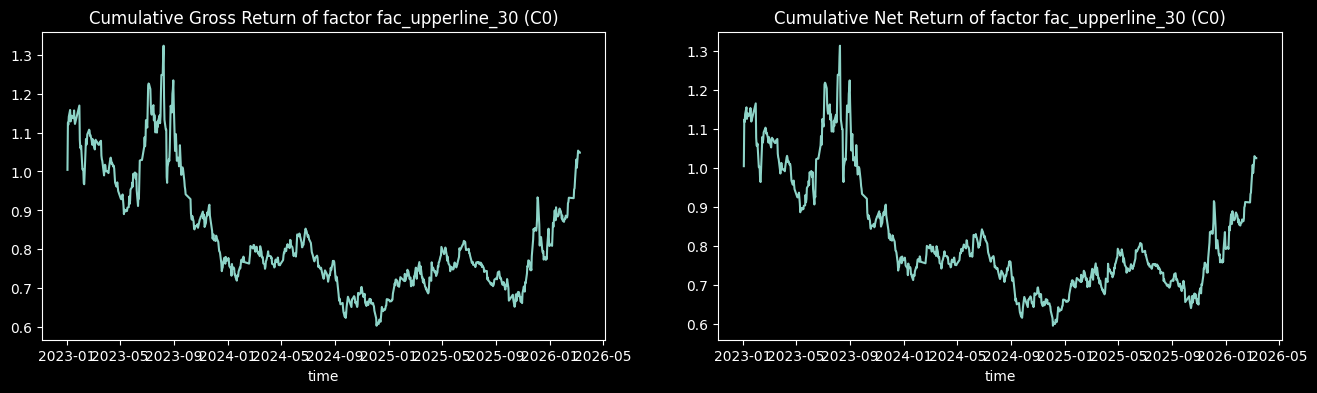

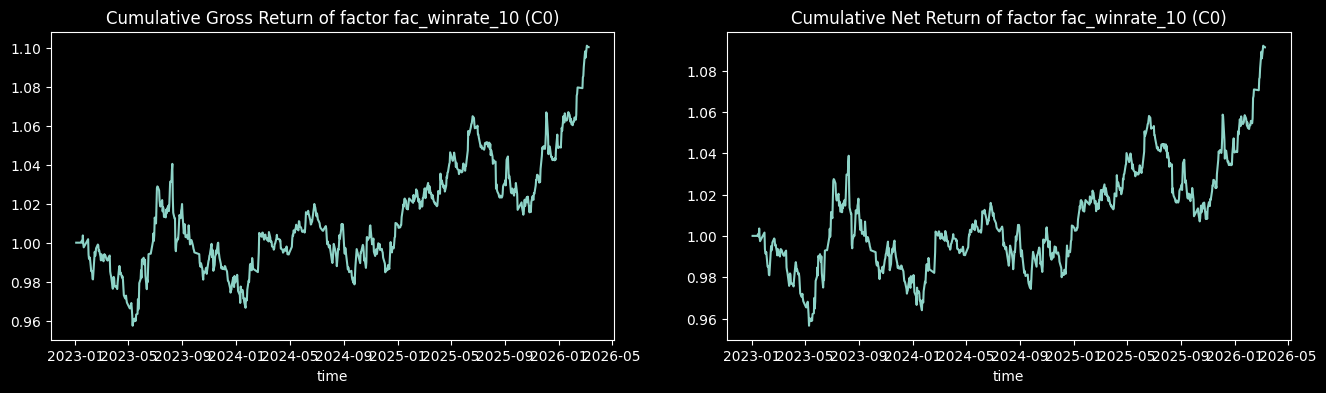

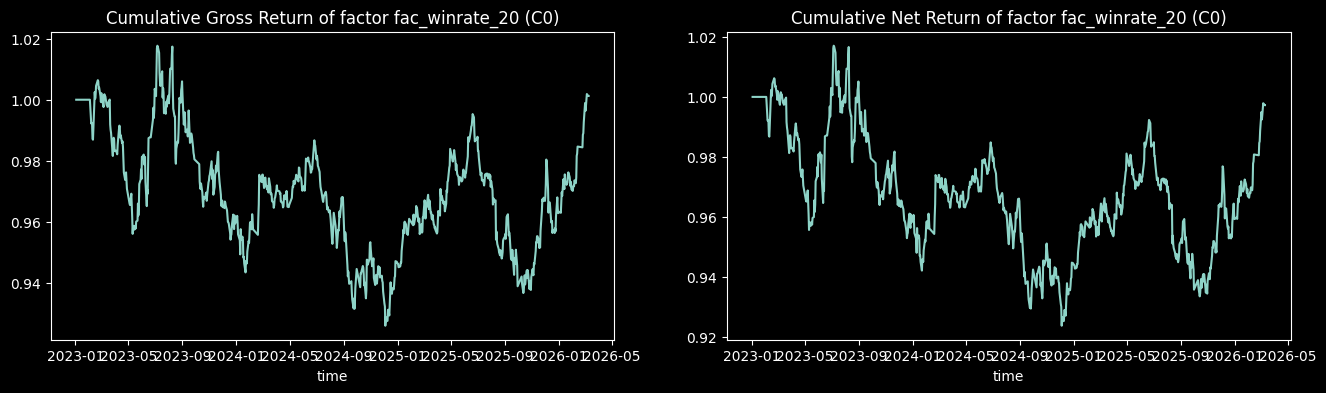

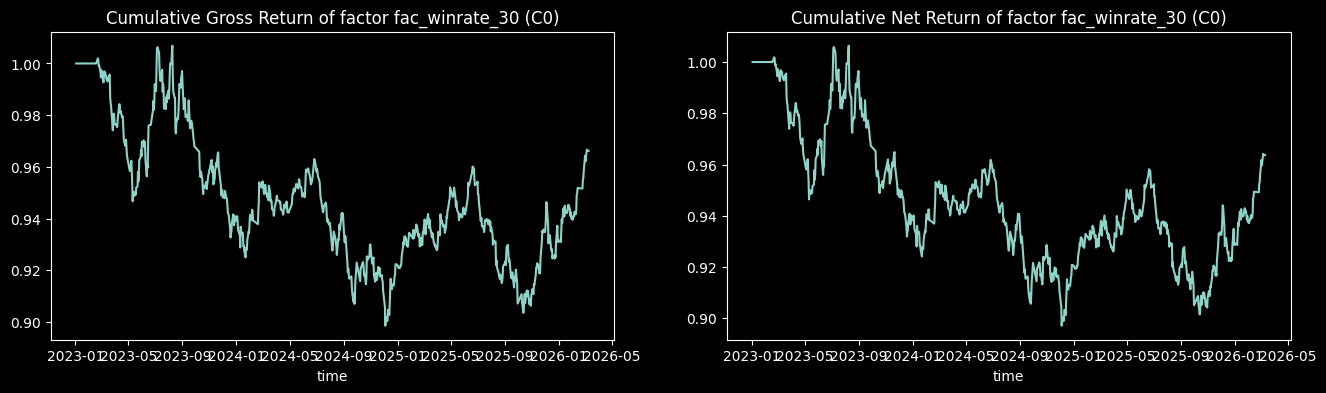

In [3]:
bt.plot_nav()